In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc
)

LOADING THE DATASET

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv( #used to read the CSV file from the specified URL and load it into a DataFrame
    url,
    sep=';',
    header=None
)

print(data.shape)

(1055, 42)


FEATURING THE DATA AND ENCODING LABELS

In [ ]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1] 

print(y.value_counts())
y = np.where(y == 'RB', 1, 0) #makes the target variable binary; RB=1 & NRB=0


41
NRB    699
RB     356
Name: count, dtype: int64


TRAIN/TEST SPLIT

In [ ]:
#splitting the dataset as 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

SCALING

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

TESTING FOR K VALUE

In [ ]:
k_values = range(1,51) 

train_scores = []
test_scores = []

for k in k_values:

    knn = KNeighborsClassifier( 
        n_neighbors=k
    )

    knn.fit(X_train_scaled, y_train) 

    train_acc = knn.score(
        X_train_scaled,
        y_train
    )

    test_acc = knn.score(
        X_test_scaled,
        y_test
    )

    train_scores.append(train_acc)
    test_scores.append(test_acc)

PLOTTING ACCURACY VS 'K' VALUE

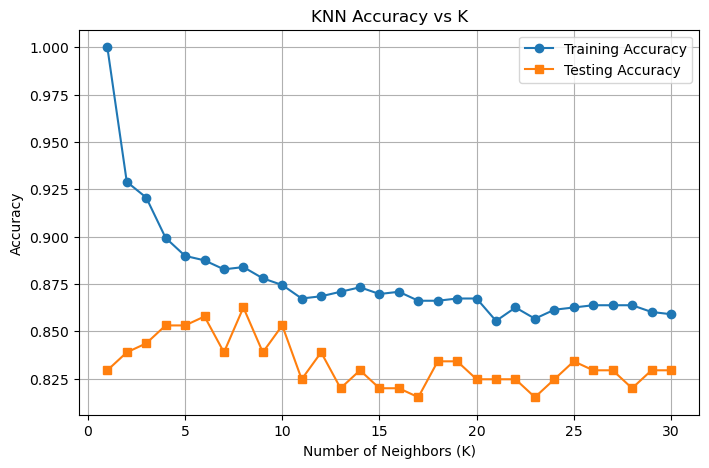

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    train_scores,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    k_values,
    test_scores,
    marker='s',
    label='Testing Accuracy'
)

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')
plt.legend()
plt.grid(True)

plt.show()

FINDING BEST K VALUE

In [33]:
best_k = k_values[np.argmax(test_scores)]

print("Best K:", best_k)
print("Best Test Accuracy:", max(test_scores))



Best K: 8
Best Test Accuracy: 0.8625592417061612


TRAINING KNN MODEL

In [49]:
best_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

best_knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=8)

PREDICTIONS & ACCURACY

In [19]:
y_pred = best_knn.predict(
    X_test_scaled
)

y_prob = best_knn.predict_proba(
    X_test_scaled
)[:,1]

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8625592417061612


ROC-AUC VALUE

In [21]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9061871227364184


CONFUSION MATRIX & CLASSIFICATION REPORT

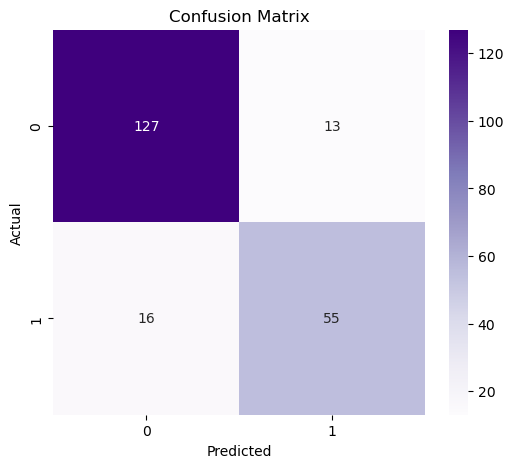


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       140
           1       0.81      0.77      0.79        71

    accuracy                           0.86       211
   macro avg       0.85      0.84      0.84       211
weighted avg       0.86      0.86      0.86       211



In [51]:
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

ROC CURVE

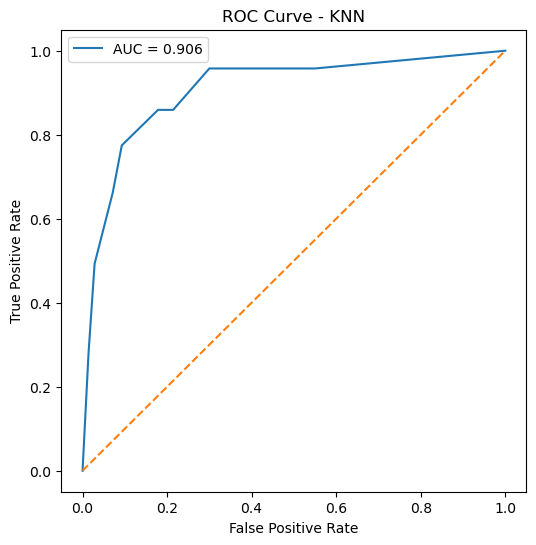

In [27]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")

plt.legend()

plt.show()

OVERFITTING ANALYSIS

In [36]:
train_acc = best_knn.score(
    X_train_scaled,
    y_train
)

test_acc = best_knn.score(
    X_test_scaled,
    y_test
)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Training Accuracy: 0.8838862559241706
Testing Accuracy : 0.8625592417061612


WEIGHTED KNN

In [46]:
weighted_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance'
)

weighted_knn.fit(
    X_train_scaled,
    y_train
)

pred = weighted_knn.predict(
    X_test_scaled
)

prob = weighted_knn.predict_proba(
    X_test_scaled
)[:,1]

print(
    "Accuracy:",
    accuracy_score(y_test,pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test,prob)
)

print("\nClassification Report:")
print(classification_report(y_test, pred))

Accuracy: 0.8672985781990521
ROC-AUC: 0.9102112676056338

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       140
           1       0.79      0.83      0.81        71

    accuracy                           0.87       211
   macro avg       0.85      0.86      0.85       211
weighted avg       0.87      0.87      0.87       211



DISTANCE METRIC COMPARISON

In [53]:
metrics = ['euclidean', 'manhattan', 'minkowski']

results = []

for metric in metrics:

    knn = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric
    )

    knn.fit(X_train_scaled, y_train)

    pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    results.append([metric, acc])

metric_results = pd.DataFrame(
    results,
    columns=['Metric', 'Accuracy']
)

print(metric_results)

      Metric  Accuracy
0  euclidean  0.862559
1  manhattan  0.876777
2  minkowski  0.862559


CROSS VALIDATION

In [40]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.90532544 0.83431953 0.87573964 0.81065089 0.83333333]
Mean CV Accuracy: 0.8518737672583827


FINDING THE BEST METRIC

In [47]:
best_metric = None
best_accuracy = 0

for metric in ['euclidean','manhattan','minkowski']:

    model = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric,
        weights='distance'
    )

    model.fit(X_train_scaled,y_train)

    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test,pred)

    if acc > best_accuracy:
        best_accuracy = acc
        best_metric = metric

print(best_metric)
print(best_accuracy)

manhattan
0.8720379146919431


In [41]:
#references: https://www.kaggle.com/code/amolbhivarkar/knn-for-classification-using-scikit-learn
